In [1]:
import os
import subprocess

if not os.path.exists("MIAM"):
    subprocess.run(["git", "clone", "https://github.com/zbirobin/MIAM.git"], check=True)
if not os.path.exists("miam-climate-stress"):
    subprocess.run(["git", "clone", "https://github.com/hugoaslm/miam-climate-stress.git"], check=True)

if os.path.basename(os.getcwd()) != "MIAM":
    os.chdir("MIAM")


In [2]:
!pip install -q -r requirements.txt
!pip install -q -e .
!pip install -q huggingface_hub kagglehub jsonlines seaborn torcheval


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.7/454.7 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.6/19.6 MB 120.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.6/186.6 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [3]:
import shutil
from huggingface_hub import hf_hub_download

for method, fname in [
    ("miam", "geoplant_miam.pt"),
    ("dropout", "geoplant_dropout.pt"),
    ("constant", "geoplant_constant.pt"),
]:
    path = hf_hub_download("zbirobin/MIAM", fname)
    os.makedirs(f"models/{method}", exist_ok=True)
    shutil.copy(path, f"models/{method}/{method}.pt")


geoplant_miam.pt: reconstructing file:   0%|          |  0.00B / 10.5MB            

geoplant_miam.pt: downloading bytes:           |  0.00B            

geoplant_dropout.pt: reconstructing file:   0%|          |  0.00B / 10.5MB            

geoplant_dropout.pt: downloading bytes:           |  0.00B            

geoplant_constant.pt: reconstructing file:   0%|          |  0.00B / 10.5MB            

geoplant_constant.pt: downloading bytes:           |  0.00B            

In [4]:
import kagglehub

files = [
    "PA_metadata_train.csv",
    "EnvironmentalValues/Climate/Average 1981-2010/PA-train-bioclimatic.csv",
    "EnvironmentalValues/Elevation/PA-train-elevation.csv",
    "EnvironmentalValues/Human Footprint/PA-train-human_footprint.csv",
    "EnvironmentalValues/LandCover/PA-train-landcover.csv",
    "EnvironmentalValues/SoilGrids/PA-train-soilgrids.csv",
    "SateliteTimeSeries-Bioclimatic/values/PA-train-bioclimatic-monthly.csv",
] + [
    f"SateliteTimeSeries-Landsat/values/PA-train-landsat_time_series/"
    f"PA-train-landsat_time_series-{b}.csv"
    for b in ("red", "green", "blue", "nir", "swir1", "swir2")
]

paths = [kagglehub.dataset_download("picekl/geoplant", path=f) for f in files]
geo_path = os.path.dirname(paths[0])


100%|██████████| 136M/136M [00:10<00:00, 13.6MB/s]


100%|██████████| 7.98M/7.98M [00:02<00:00, 4.03MB/s]


100%|██████████| 1.08M/1.08M [00:01<00:00, 790kB/s]


100%|██████████| 6.57M/6.57M [00:02<00:00, 3.38MB/s]


100%|██████████| 1.04M/1.04M [00:01<00:00, 759kB/s]


...

100%|██████████| 33.5M/33.5M [00:03<00:00, 8.99MB/s]


100%|██████████| 28.3M/28.3M [00:03<00:00, 8.76MB/s]


100%|██████████| 34.1M/34.1M [00:03<00:00, 9.31MB/s]


100%|██████████| 33.8M/33.8M [00:03<00:00, 9.35MB/s]


100%|██████████| 33.6M/33.6M [00:03<00:00, 8.94MB/s]


In [5]:
STRESS_REPO = os.path.join(os.path.dirname(os.getcwd()), "miam-climate-stress")
!mkdir -p ../results ../figures


In [6]:
!python $STRESS_REPO/scripts/evaluate_climate_stress.py \
    --data_dir $geo_path \
    --checkpoints miam dropout constant \
    --output_dir ../results \
    --batch_size 256 \
    --no_satellite


/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [7]:
!python $STRESS_REPO/scripts/plot_climate_stress.py \
    --results ../results/climate_stress_results.csv \
    --output_dir ../figures \
    --format png


Loaded 33 results for 3 methods, 11 conditions
Saved: ../figures/clean_vs_stress.png
Saved: ../figures/modality_ablation_drop.png
Saved: ../figures/climate_noise_curve.png
Saved: ../figures/month_dropout_curve.png
Saved: ../figures/robustness_summary.png

All figures saved to: ../figures/


In [8]:
import pandas as pd

df = pd.read_csv("../results/climate_stress_results.csv")
pivot = df.pivot_table(values="auroc", index="condition", columns="method", aggfunc="first")
for method in pivot.columns:
    if "clean" in pivot.index:
        pivot[f"{method}_robustness"] = pivot[method] / pivot.loc["clean", method]
pivot.round(4).to_csv("../results/climate_stress_summary.csv")
print(pivot.round(4).to_string())


method             constant  dropout    miam  constant_robustness  dropout_robustness  miam_robustness
condition                                                                                             
clean                0.8992   0.9196  0.9167               1.0000              1.0000           1.0000
climate_drop_025     0.8930   0.9183  0.9122               0.9931              0.9986           0.9951
climate_drop_050     0.8762   0.9163  0.9070               0.9744              0.9964           0.9894
climate_drop_075     0.8462   0.9154  0.9060               0.9410              0.9955           0.9883
climate_missing      0.8577   0.9158  0.9171               0.9539              0.9959           1.0004
climate_noise_025    0.8989   0.9192  0.9163               0.9996              0.9996           0.9995
climate_noise_050    0.8968   0.9181  0.9133               0.9973              0.9984           0.9963
climate_noise_100    0.8848   0.9153  0.8888               0.9840        

In [9]:
df = pd.read_csv("../results/climate_stress_results.csv")
for method in df["method"].unique():
    m = df[df["method"] == method]
    clean = m[m["condition"] == "clean"]["auroc"].values[0]
    cm = m[m["condition"] == "climate_missing"]
    drop = clean - cm["auroc"].values[0] if len(cm) else float("nan")
    noise = m[m["condition"].str.contains("noise")]["auroc"]
    line = f"{method}: clean={clean:.4f} climate_missing_drop={drop:+.4f}"
    if len(noise):
        line += f" worst_noise={noise.min():.4f}"
    print(line)


miam: clean=0.9167 climate_missing_drop=-0.0004 worst_noise=0.8888
dropout: clean=0.9196 climate_missing_drop=+0.0038 worst_noise=0.9153
constant: clean=0.8992 climate_missing_drop=+0.0415 worst_noise=0.8848


method                        constant   dropout      miam
condition                                                 
Bio1                          0.685794  0.486681  0.784329
Worldclim                     0.823594  0.808327  0.867039
all                           0.879490  0.920491  0.916640
center_patch                  0.551280  0.662087  0.707539
clim_2018                     0.847074  0.773805  0.859724
climatic_timeseries           0.867198  0.864485  0.869794
sentinel2_patches             0.635563  0.731867  0.800919
tabular                       0.833207  0.885930  0.890135
tabular+sentinel2_patches     0.833025  0.891978  0.895035
tabular+timeseries            0.899733  0.919893  0.916582
timeseries                    0.899537  0.913715  0.913626
timeseries+sentinel2_patches  0.891840  0.917227  0.915470


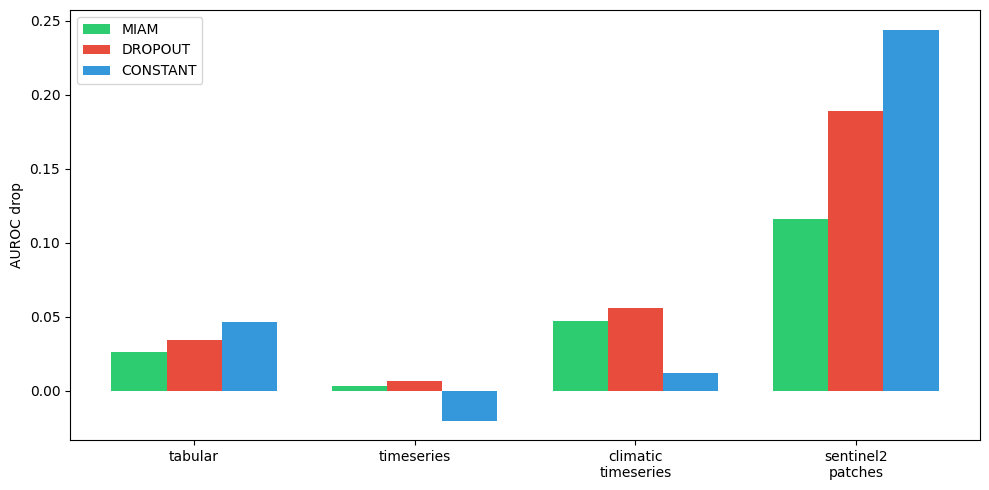

In [10]:
import json
import matplotlib.pyplot as plt
import numpy as np

rows = []
for method in ["miam", "modality_dropout", "constant"]:
    result_file = f"figures_tables/table_1/results/{method}/all_together.jsonl"
    if os.path.exists(result_file):
        with open(result_file) as f:
            for line in f:
                row = json.loads(line)
                rows.append({
                    "method": method.replace("modality_dropout", "dropout"),
                    "condition": row["variables"],
                    "auroc": row["test_auroc"],
                })

fallback_df = pd.DataFrame(rows)
print(fallback_df.pivot_table(values="auroc", index="condition", columns="method"))

fig, ax = plt.subplots(figsize=(10, 5))
conditions_plot = ["tabular", "timeseries", "climatic_timeseries", "sentinel2_patches"]
colors = {"miam": "#2ecc71", "dropout": "#e74c3c", "constant": "#3498db"}
x = np.arange(len(conditions_plot))
width = 0.25
for i, method in enumerate(["miam", "dropout", "constant"]):
    m = fallback_df[fallback_df["method"] == method]
    all_score = m[m["condition"] == "all"]["auroc"].values[0]
    scores = []
    for cond in conditions_plot:
        r = m[m["condition"] == cond]
        scores.append(all_score - r["auroc"].values[0] if len(r) > 0 else np.nan)
    ax.bar(x + i * width, scores, width, label=method.upper(), color=colors[method])
ax.set_xticks(x + width)
ax.set_xticklabels([c.replace("_", "\n") for c in conditions_plot])
ax.set_ylabel("AUROC drop")
ax.legend()
plt.tight_layout()
plt.savefig("../figures/modality_sensitivity_fallback.png", dpi=150)
plt.show()


In [11]:
from google.colab import drive
import shutil
import datetime

drive.mount("/content/drive")

stamp = datetime.datetime.now().strftime("%Y%m%d-%H%M")
dest = f"/content/drive/MyDrive/miam-climate-stress-results/{stamp}"
os.makedirs(dest, exist_ok=True)

for p in ["../results", "../figures"]:
    shutil.copytree(p, f"{dest}/{os.path.basename(p)}")

print(f"Saved results to {dest}")

Mounted at /content/drive
Saved results to /content/drive/MyDrive/miam-climate-stress-results/20260801-2059
